In [2]:
import os
from sklearn.model_selection import train_test_split
import shutil
import random
import time
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets , models , transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from torch import optim
import torch.nn.functional as F

import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

In [6]:
base_folder = r'/content/drive/My Drive/Dataset'  # in New Folder create Dataset as subfolder and that subfolder contains different classes i.e., Flowering, Growing, Mature, Seeding and Wilting
dataset_folder = os.path.join(base_folder, 'Dataset')
new_folder = os.path.join(base_folder, 'data')

In [7]:
class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
class_folders

['Curl Virus',
 'White spot',
 'Nutrition Deficiency',
 'Healthy Leaf',
 'Cercospora Leaf Spot',
 'Bacterial Spot']

In [8]:
os.makedirs(new_folder, exist_ok=True)

In [9]:
import random

In [10]:
for class_folder in class_folders:
    class_path = os.path.join(dataset_folder, class_folder)
    images = os.listdir(class_path)

    # Shuffle the images randomly
    random.shuffle(images)

    # Split the images into train, test, and validation sets
    train_images, temp_images = train_test_split(images, train_size=0.7, random_state=42)
    test_images, val_images = train_test_split(temp_images, train_size=0.5, random_state=42)

    # Create folders for train, test, and validation sets within the 'data' folder
    train_folder = os.path.join(new_folder, 'train', class_folder)
    test_folder = os.path.join(new_folder, 'test', class_folder)
    val_folder = os.path.join(new_folder, 'val', class_folder)

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)
    os.makedirs(val_folder, exist_ok=True)

    # Move images to the respective folders
    for image in train_images:
        shutil.move(os.path.join(class_path, image), os.path.join(train_folder, image))

    for image in test_images:
        shutil.move(os.path.join(class_path, image), os.path.join(test_folder, image))

    for image in val_images:
        shutil.move(os.path.join(class_path, image), os.path.join(val_folder, image))


In [11]:
train_folder = os.path.join(new_folder, 'train')
num_total_train_images = sum(len(files) for _, _, files in os.walk(train_folder))

test_folder = os.path.join(new_folder, 'test')
num_total_test_images = sum(len(files) for _, _, files in os.walk(test_folder))

val_folder = os.path.join(new_folder, 'val')
num_total_val_images = sum(len(files) for _, _, files in os.walk(val_folder))

print(f"Total Train Images: {num_total_train_images}")
print(f"Total Test Images: {num_total_test_images}")
print(f"Total Validation Images: {num_total_val_images}")


Total Train Images: 1264
Total Test Images: 272
Total Validation Images: 275


# **DATA LOADERS**

In [12]:
mean_values = [0.485, 0.456, 0.406]
std_values = [0.229, 0.224, 0.225]

In [13]:
normalize = transforms.Normalize(mean=mean_values, std=std_values)

In [14]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(30),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

test_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

In [15]:
# Create custom dataset
train_dataset = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(new_folder, 'val'), transform=val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(new_folder, 'test'), transform=test_transforms)

In [16]:
data_loaders = {x: DataLoader(
                    datasets.ImageFolder(os.path.join(new_folder, x),
                                         transform=train_transforms if x == 'train' else
                                                   val_transforms if x == 'val' else test_transforms),
                    batch_size=32,
                    shuffle=True if x == 'train' else False)
                for x in ['train', 'val', 'test']}

In [17]:
dataset_sizes = {x: len(datasets.ImageFolder(os.path.join(new_folder, x),
                 transform=train_transforms if x == 'train' else val_transforms if x == 'val' else test_transforms))
                 for x in ['train', 'val', 'test']}

class_names = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms).classes

In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [19]:
class_names, device , dataset_sizes

(['Bacterial Spot',
  'Cercospora Leaf Spot',
  'Curl Virus',
  'Healthy Leaf',
  'Nutrition Deficiency',
  'White spot'],
 device(type='cuda', index=0),
 {'train': 1264, 'val': 275, 'test': 272})

# **VGG16**

In [ ]:
model_ft = models.vgg16(pretrained=True)
model_ft

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 81.5MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,features.0.weight,1728
1,features.0.bias,64
2,features.2.weight,36864
3,features.2.bias,64
4,features.5.weight,73728
5,features.5.bias,128
6,features.7.weight,147456
7,features.7.bias,128
8,features.10.weight,294912
9,features.10.bias,256


In [ ]:
for parameters in model_ft.parameters():
  parameters.requires_grad = False

In [ ]:
count_params(model_ft)

,Modules,Parameters


In [ ]:
model_ft.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [ ]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_ft)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,classifier.0.weight,2508800
1,classifier.0.bias,100
2,classifier.3.weight,600
3,classifier.3.bias,6


In [ ]:
model_ft.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=100, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_ft)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,classifier.0.weight,2508800
1,classifier.0.bias,100
2,classifier.3.weight,600
3,classifier.3.bias,6


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    '''
    Function to train and validate with early stopping
    Parameters
        :param model: Model to train and validate
        :param loss_criterion: Loss Criterion to minimize
        :param optimizer: Optimizer for computing gradients
        :param train_data_loader: DataLoader for training data
        :param valid_data_loader: DataLoader for validation data
        :param epochs: Number of epochs (default=25)
        :param patience: Number of epochs with no improvement after which training will be stopped (default=3)

    Returns
        model: Trained Model with best validation accuracy
        history: (list): List of lists containing training loss, validation loss, training accuracy, and validation accuracy for each epoch
    '''

    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(epoch + 1, avg_train_loss, avg_train_acc * 100, avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history


In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

Epoch: 1/100


Validation: 100%|██████████| 9/9 [01:59<00:00, 13.30s/it]


Epoch : 001, Training: Loss: 0.9996, Accuracy: 65.5093%, 
		Validation : Loss : 0.3515, Accuracy: 87.2340%, Time: 661.7474s
Epoch: 2/100


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.28it/s]


Epoch : 002, Training: Loss: 0.3843, Accuracy: 87.4228%, 
		Validation : Loss : 0.2308, Accuracy: 92.9078%, Time: 39.3250s
Epoch: 3/100


...

Epoch : 026, Training: Loss: 0.0958, Accuracy: 96.9136%, 
		Validation : Loss : 0.1383, Accuracy: 97.1631%, Time: 40.0341s
Epoch: 27/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.36it/s]


Epoch : 027, Training: Loss: 0.0962, Accuracy: 96.6821%, 
		Validation : Loss : 0.1883, Accuracy: 96.8085%, Time: 39.9701s
Epoch: 28/100


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.28it/s]

Epoch : 028, Training: Loss: 0.0927, Accuracy: 96.1420%, 
		Validation : Loss : 0.1930, Accuracy: 95.7447%, Time: 40.1389s
Early stopping after 20 epochs with no improvement.
Training complete in 29m 18s


In [ ]:
print(trained_model1)

(VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [ ]:
trained_model, history_values = trained_model1

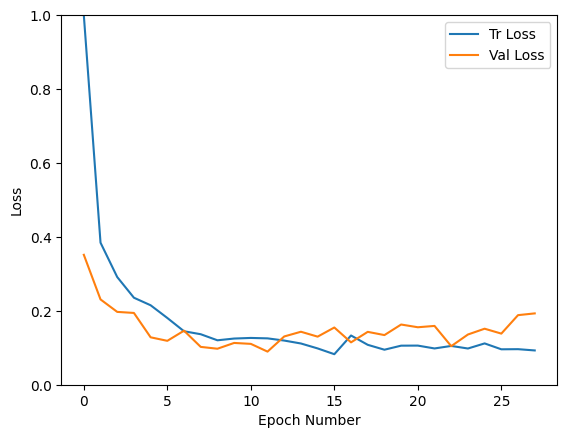

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

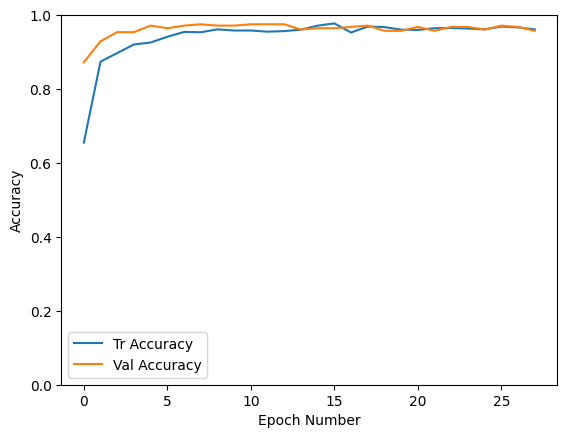

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(data_loaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [ ]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

test Epoch: 100%|██████████| 9/9 [00:06<00:00,  1.47batch/s, accuracy=0.95]


              precision    recall  f1-score   support

           0       0.70      0.91      0.79        23
           1       1.00      0.59      0.74        27
           2       0.95      1.00      0.98        63
           3       0.97      0.99      0.98        69
           4       1.00      1.00      1.00        67
           5       1.00      1.00      1.00        29

    accuracy                           0.95       278
   macro avg       0.94      0.92      0.92       278
weighted avg       0.96      0.95      0.95       278

test Acc: 0.9496


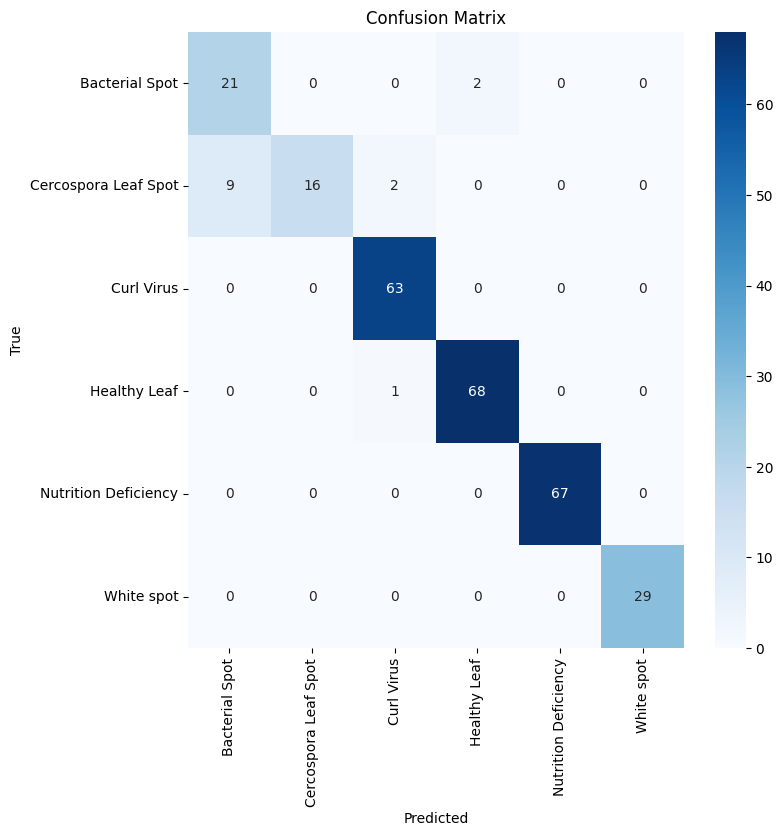

In [ ]:
test_model(trained_model)

# **VGG19**

In [ ]:
model_ft = models.vgg19(pretrained=True)
model_ft

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 66.6MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

,Modules,Parameters
0,features.0.weight,1728
1,features.0.bias,64
2,features.2.weight,36864
3,features.2.bias,64
4,features.5.weight,73728
5,features.5.bias,128
6,features.7.weight,147456
7,features.7.bias,128
8,features.10.weight,294912
9,features.10.bias,256


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    '''
    Function to train and validate with early stopping
    Parameters
        :param model: Model to train and validate
        :param loss_criterion: Loss Criterion to minimize
        :param optimizer: Optimizer for computing gradients
        :param train_data_loader: DataLoader for training data
        :param valid_data_loader: DataLoader for validation data
        :param epochs: Number of epochs (default=25)
        :param patience: Number of epochs with no improvement after which training will be stopped (default=3)

    Returns
        model: Trained Model with best validation accuracy
        history: (list): List of lists containing training loss, validation loss, training accuracy, and validation accuracy for each epoch
    '''

    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(epoch + 1, avg_train_loss, avg_train_acc * 100, avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history

In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

Epoch: 1/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.41it/s]


Epoch : 001, Training: Loss: 11.8075, Accuracy: 22.4537%, 
		Validation : Loss : 1.7364, Accuracy: 23.7589%, Time: 58.9411s
Epoch: 2/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.34it/s]


Epoch : 002, Training: Loss: 1.4848, Accuracy: 37.9630%, 
		Validation : Loss : 1.7132, Accuracy: 39.3617%, Time: 58.7909s
Epoch: 3/100


...

Epoch : 052, Training: Loss: 0.3499, Accuracy: 87.8858%, 
		Validation : Loss : 0.7857, Accuracy: 78.0142%, Time: 59.5348s
Epoch: 53/100


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.15it/s]


Epoch : 053, Training: Loss: 0.5685, Accuracy: 80.9414%, 
		Validation : Loss : 0.3955, Accuracy: 85.4610%, Time: 62.2805s
Epoch: 54/100


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.27it/s]

Epoch : 054, Training: Loss: 0.3383, Accuracy: 88.5031%, 
		Validation : Loss : 0.5970, Accuracy: 84.3972%, Time: 62.2426s
Early stopping after 20 epochs with no improvement.
Training complete in 53m 43s


In [ ]:
print(trained_model1)

(VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pad

In [ ]:
trained_model, history_values = trained_model1

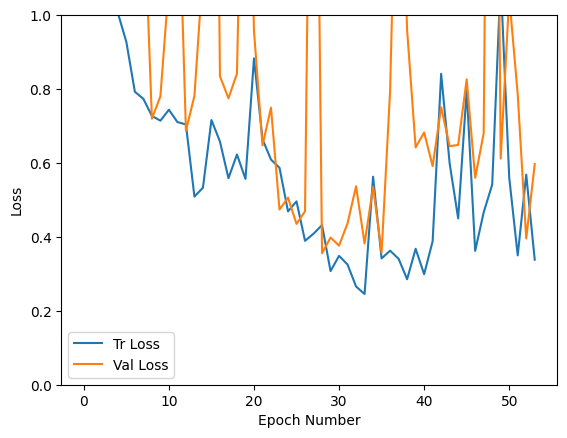

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

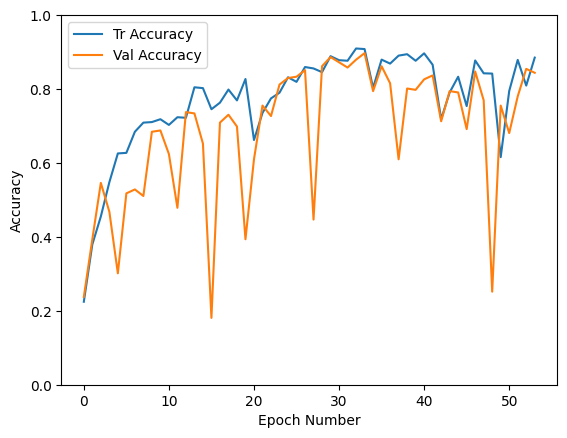

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [ ]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

test Epoch: 100%|██████████| 9/9 [00:06<00:00,  1.31batch/s, accuracy=0.827]


              precision    recall  f1-score   support

           0       0.53      0.43      0.48        23
           1       0.86      0.70      0.78        27
           2       1.00      1.00      1.00        63
           3       0.96      0.94      0.95        69
           4       0.75      0.66      0.70        67
           5       0.62      1.00      0.76        29

    accuracy                           0.83       278
   macro avg       0.78      0.79      0.78       278
weighted avg       0.84      0.83      0.82       278

test Acc: 0.8273


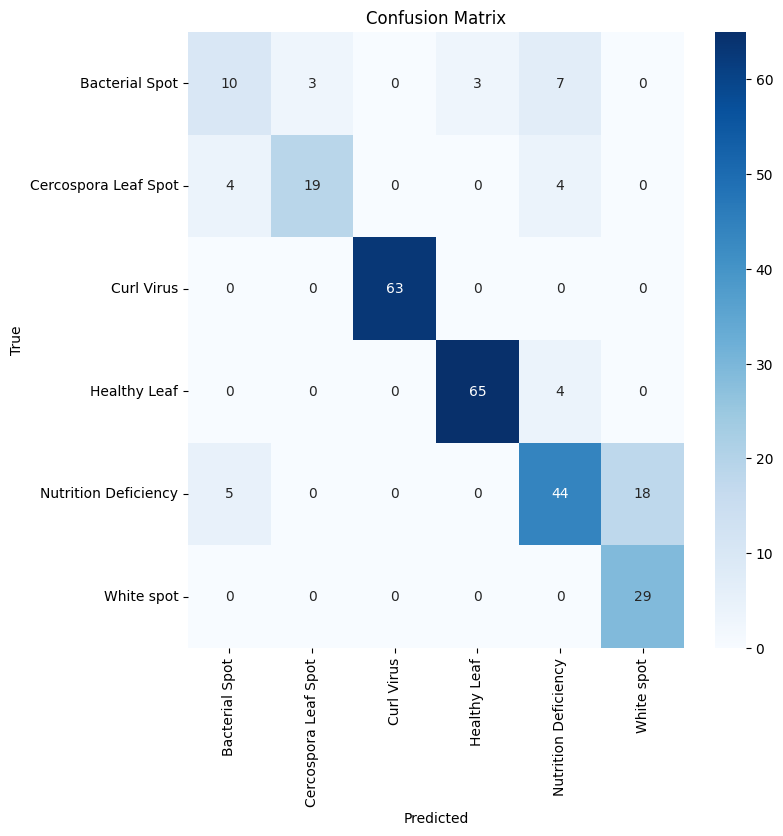

In [ ]:
test_model(trained_model)

# **AlexNet**

In [ ]:
model_alexnet = models.alexnet(pretrained=True)
model_alexnet

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 140MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
count_params(model_alexnet)

,Modules,Parameters
0,features.0.weight,23232
1,features.0.bias,64
2,features.3.weight,307200
3,features.3.bias,192
4,features.6.weight,663552
5,features.6.bias,384
6,features.8.weight,884736
7,features.8.bias,256
8,features.10.weight,589824
9,features.10.bias,256


In [ ]:
for parameters in model_alexnet.parameters():
  parameters.requires_grad = False

In [ ]:
count_params(model_alexnet)

,Modules,Parameters


In [ ]:
model_alexnet.classifier

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [ ]:
model_alexnet.classifier = nn.Sequential(
    nn.Linear(in_features=9216, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_alexnet)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=100, bias=True)
    (1): ReLU(inplace=True)
    (2): Drop

In [ ]:
count_params(model_alexnet)

,Modules,Parameters
0,classifier.0.weight,921600
1,classifier.0.bias,100
2,classifier.3.weight,600
3,classifier.3.bias,6


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_alexnet.parameters())

In [ ]:
trained_model2 = train_and_validate(model_alexnet, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

Epoch: 1/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.55it/s]


Epoch : 001, Training: Loss: 1.0054, Accuracy: 64.2747%, 
		Validation : Loss : 0.3459, Accuracy: 88.6525%, Time: 33.0373s
Epoch: 2/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.51it/s]


Epoch : 002, Training: Loss: 0.4166, Accuracy: 85.4167%, 
		Validation : Loss : 0.2218, Accuracy: 94.3262%, Time: 32.9619s
Epoch: 3/100


...

Epoch : 042, Training: Loss: 0.0789, Accuracy: 97.1451%, 
		Validation : Loss : 0.1606, Accuracy: 98.2270%, Time: 33.2732s
Epoch: 43/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.63it/s]


Epoch : 043, Training: Loss: 0.0843, Accuracy: 96.9907%, 
		Validation : Loss : 0.1801, Accuracy: 97.5177%, Time: 33.2070s
Epoch: 44/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.77it/s]

Epoch : 044, Training: Loss: 0.0819, Accuracy: 96.9136%, 
		Validation : Loss : 0.1604, Accuracy: 97.1631%, Time: 31.2642s
Early stopping after 20 epochs with no improvement.
Training complete in 23m 7s


In [ ]:
print(trained_model2)

(AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=100, bias=True)
    (1): ReLU(inplace=True)
    (2): Dro

In [ ]:
alexnet_trained_model, alexnet_history_values = trained_model2

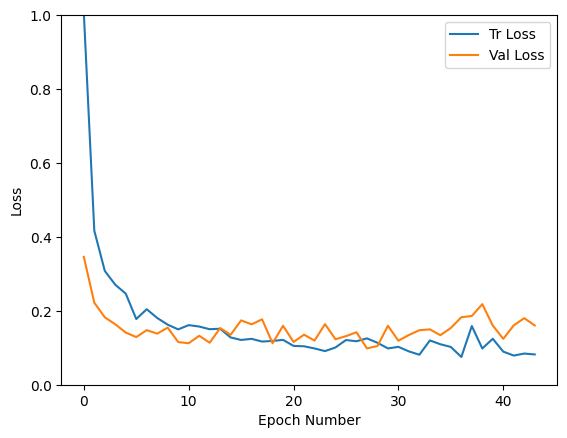

In [ ]:
history = np.array(alexnet_history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

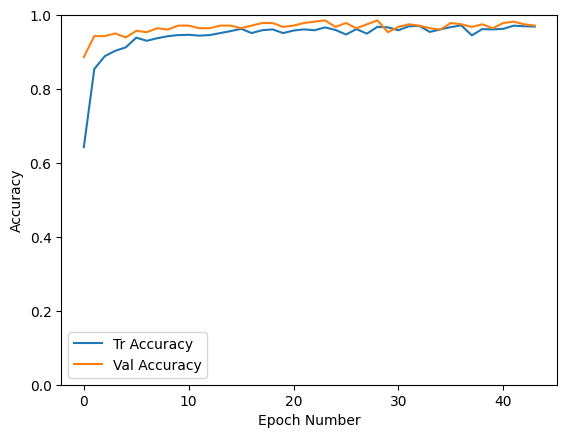

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

test Epoch: 100%|██████████| 9/9 [00:06<00:00,  1.49batch/s, accuracy=0.971]


              precision    recall  f1-score   support

           0       0.90      0.83      0.86        23
           1       0.96      0.89      0.92        27
           2       0.97      1.00      0.98        63
           3       0.96      0.99      0.97        69
           4       1.00      1.00      1.00        67
           5       1.00      1.00      1.00        29

    accuracy                           0.97       278
   macro avg       0.97      0.95      0.96       278
weighted avg       0.97      0.97      0.97       278

test Acc: 0.9712


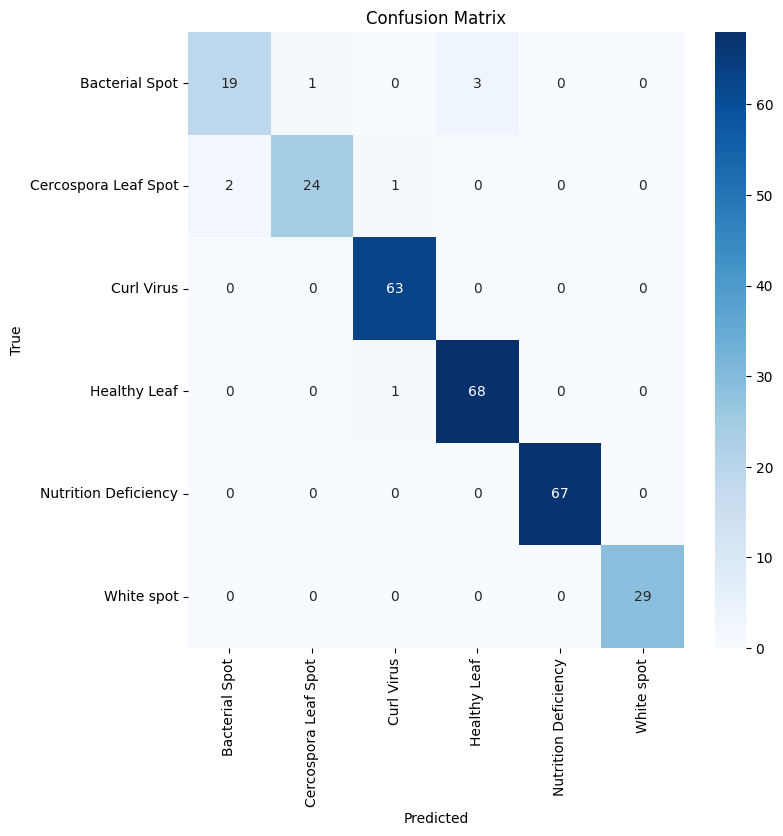

In [ ]:
test_model(alexnet_trained_model)

# **MobileNetv3**

In [20]:
import torch
import torch.nn as nn
import torchvision.models as models

In [21]:
# Load MobileNetV3 (Large version)
model_ft = models.mobilenet_v3_large(pretrained=True)
print(model_ft)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 117MB/s] 


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [22]:
for param in model_ft.parameters():
    param.requires_grad = False

In [23]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=960, out_features=128),
    nn.Hardswish(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=128, out_features=6)
)

print(model_ft)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [25]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [26]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)


Epoch 1/100


Validation: 100%|██████████| 9/9 [01:35<00:00, 10.64s/it]


Train Loss: 1.6055, Acc: 0.4802
Val   Loss: 1.5668, Acc: 0.6800

Epoch 2/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.48it/s]


Train Loss: 1.3631, Acc: 0.6582
Val   Loss: 1.2736, Acc: 0.7055

Epoch 3/100


...

Train Loss: 0.1829, Acc: 0.9541
Val   Loss: 0.1221, Acc: 0.9673

Epoch 36/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


Train Loss: 0.1693, Acc: 0.9573
Val   Loss: 0.1083, Acc: 0.9782

Epoch 37/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.35it/s]

Train Loss: 0.1512, Acc: 0.9597
Val   Loss: 0.1150, Acc: 0.9673
Early stopping triggered


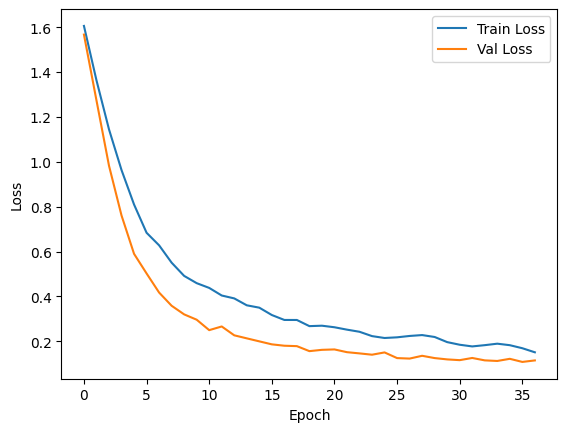

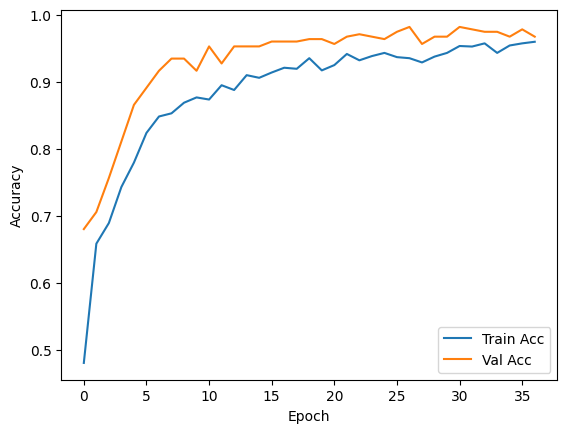

In [27]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
def test_model_mobilenetv3(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

test Epoch: 100%|██████████| 9/9 [01:41<00:00, 11.32s/batch, accuracy=0.982]


              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       1.00      0.89      0.94        27
           2       0.98      1.00      0.99        63
           3       0.99      0.99      0.99        69
           4       0.99      1.00      0.99        67
           5       1.00      1.00      1.00        29

    accuracy                           0.98       272
   macro avg       0.97      0.97      0.97       272
weighted avg       0.98      0.98      0.98       272

test Acc: 0.9816


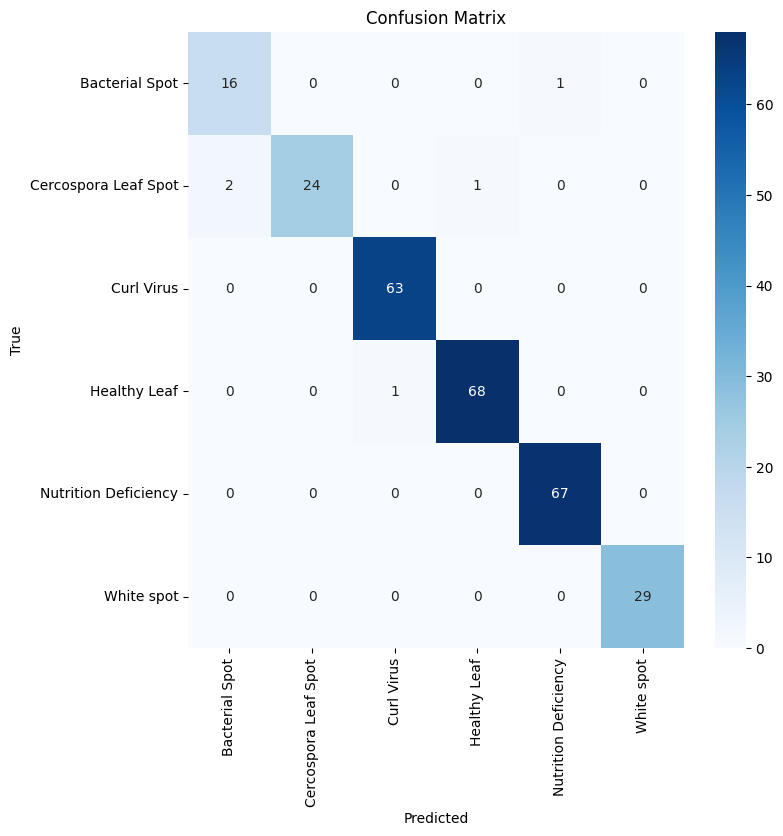

In [29]:
test_model_mobilenetv3(model_ft)

## **ShuffleNet**

In [30]:
model_ft = models.shufflenet_v2_x1_0(pretrained=True)
print(model_ft)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 80.1MB/s]


ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_

In [31]:
for param in model_ft.parameters():
    param.requires_grad = False

In [32]:
num_classes = 6

model_ft.fc = nn.Sequential(
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

print(model_ft)

ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [34]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)


Epoch 1/100


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.28it/s]


Train Loss: 1.7652, Acc: 0.2991
Val   Loss: 1.7502, Acc: 0.4255

Epoch 2/100


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.56it/s]


Train Loss: 1.7303, Acc: 0.3813
Val   Loss: 1.7181, Acc: 0.4764

Epoch 3/100


...

Validation: 100%|██████████| 9/9 [00:05<00:00,  1.57it/s]


Train Loss: 0.4919, Acc: 0.8742
Val   Loss: 0.4217, Acc: 0.9018

Epoch 63/100


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.34it/s]


Train Loss: 0.5026, Acc: 0.8671
Val   Loss: 0.3915, Acc: 0.9164

Epoch 64/100


Training:  45%|████▌     | 18/40 [00:13<00:18,  1.17it/s]

In [ ]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
def test_model_shufflenet(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model_shufflenet(model_ft)

# **VGG19 on 80/20 split**

In [ ]:
model_ft = models.vgg19(pretrained=True)
model_ft

In [ ]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    '''
    Function to train and validate with early stopping
    Parameters
        :param model: Model to train and validate
        :param loss_criterion: Loss Criterion to minimize
        :param optimizer: Optimizer for computing gradients
        :param train_data_loader: DataLoader for training data
        :param valid_data_loader: DataLoader for validation data
        :param epochs: Number of epochs (default=25)
        :param patience: Number of epochs with no improvement after which training will be stopped (default=3)

    Returns
        model: Trained Model with best validation accuracy
        history: (list): List of lists containing training loss, validation loss, training accuracy, and validation accuracy for each epoch
    '''

    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(epoch + 1, avg_train_loss, avg_train_acc * 100, avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history

In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

In [ ]:
print(trained_model1)

In [ ]:
trained_model, history_values = trained_model1

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [ ]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model(trained_model)